# Joe's Pond PRISM-Only Ice-Out Notebook

This notebook switches the climate side entirely to PRISM gridded data (point time series exports), while reusing the same ice-out results dataset.

## Inputs
- Ice-out data: `data/joes_pond_iceout.csv`
- PRISM daily time-series CSV exports: `data/prism_timeseries/*.csv`

Recommended PRISM exports from Data Explorer (single-location, Joe's Pond coordinates):
- `tmean` (required)
- `ppt` (required)
- `tmin` (optional)
- `tmax` (optional)

Use metric units and no interpolation for baseline consistency.

## 0) Setup

In [1]:
from pathlib import Path
import re
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

DATA_DIR = Path("data")
ICEOUT_CSV = DATA_DIR / "joes_pond_iceout.csv"
PRISM_DIR = DATA_DIR / "prism_timeseries"

# Joe's Pond coordinates (used when exporting PRISM data)
JOES_POND_LAT = 44.40887152650143
JOES_POND_LON = -72.2000267441201

PREDICTION_YEAR = 2026
FIXED_WINDOW_START = (1, 1)
FIXED_WINDOW_END = (3, 21)

## 1) Load ice-out dataset (same cached results file)

In [2]:
if not ICEOUT_CSV.exists():
    raise FileNotFoundError(f"Missing required file: {ICEOUT_CSV}")

ice = pd.read_csv(ICEOUT_CSV, parse_dates=["date"])
ice = ice.sort_values("year").reset_index(drop=True)

if "minutes_since_midnight" not in ice.columns:
    # Rebuild if needed from HH:MM
    hhmm = ice["time_hhmm"].astype(str).str.split(":", expand=True)
    ice["minutes_since_midnight"] = pd.to_numeric(hhmm[0], errors="coerce") * 60 + pd.to_numeric(hhmm[1], errors="coerce")

ice["doy"] = ice["date"].dt.dayofyear
ice[["year", "date", "doy", "minutes_since_midnight"]].head()

,year,date,doy,minutes_since_midnight
0,1988,1988-04-26,117,751
1,1989,1989-05-05,125,545
2,1990,1990-04-26,116,580
3,1991,1991-04-22,112,256
4,1992,1992-05-06,127,79


## 2) Load PRISM daily point time series files

Place PRISM CSV files in `data/prism_timeseries/`.
This loader is tolerant of filename/column differences across PRISM exports.

In [3]:
PRISM_DIR.mkdir(parents=True, exist_ok=True)

csv_files = sorted(PRISM_DIR.glob("*.csv"))
print(f"Found {len(csv_files)} PRISM CSV file(s) in {PRISM_DIR}")
for f in csv_files:
    print("-", f.name)

if len(csv_files) == 0:
    raise FileNotFoundError(
        "No PRISM CSV files found. Export daily point series from PRISM Data Explorer and place them in data/prism_timeseries/."
    )

Found 3 PRISM CSV file(s) in data/prism_timeseries
- PRISM_ppt_tmin_tmean_tmax_Preliminary_800m_19810101_20260321_44.4089_-72.2000.csv
- PRISM_ppt_tmin_tmean_tmax_early_800m_19810101_20260228_44.4089_-72.2000.csv
- PRISM_ppt_tmin_tmean_tmax_early_800m_19810101_20260313_44.4060_-72.2102.csv


In [4]:
def _find_prism_header_line(path: Path):
    # PRISM time-series exports often include metadata lines before the CSV header.
    with path.open("r", encoding="utf-8", errors="replace") as f:
        for i, line in enumerate(f):
            if line.strip().lower().startswith("date,"):
                return i
    return None


def _normalize_prism_col(c):
    c = str(c).strip().lower()
    # remove unit suffixes, e.g. "ppt (mm)" -> "ppt"
    c = re.sub(r"\s*\([^)]*\)", "", c)
    c = c.replace(" ", "")

    if c in {"date", "day"}:
        return "DATE"
    if c.startswith("ppt"):
        return "ppt"
    if c.startswith("tmean"):
        return "tmean"
    if c.startswith("tmin"):
        return "tmin"
    if c.startswith("tmax"):
        return "tmax"
    return c


def load_prism_csv(path: Path):
    header_line = _find_prism_header_line(path)
    if header_line is None:
        # fallback for already-clean CSV
        df = pd.read_csv(path, low_memory=False)
    else:
        df = pd.read_csv(path, skiprows=header_line, low_memory=False)

    df = df.rename(columns={c: _normalize_prism_col(c) for c in df.columns})

    if "DATE" not in df.columns:
        raise ValueError(f"Could not identify DATE column in {path.name}")

    keep = [c for c in ["DATE", "ppt", "tmin", "tmean", "tmax"] if c in df.columns]
    out = df[keep].copy()
    out["DATE"] = pd.to_datetime(out["DATE"], errors="coerce")

    for c in keep:
        if c != "DATE":
            out[c] = pd.to_numeric(out[c], errors="coerce")

    out = out.dropna(subset=["DATE"]).sort_values("DATE").reset_index(drop=True)
    return out


loaded_frames = []
for f in csv_files:
    d = load_prism_csv(f)
    loaded_frames.append(d)

prism_daily = loaded_frames[0]
for d in loaded_frames[1:]:
    # Prefer first non-null when overlapping columns are present.
    merged = prism_daily.merge(d, on="DATE", how="outer", suffixes=("_a", "_b"))
    out = pd.DataFrame({"DATE": merged["DATE"]})

    candidate_cols = set([c.replace("_a", "").replace("_b", "") for c in merged.columns if c != "DATE"])
    for base in sorted(candidate_cols):
        a = f"{base}_a"
        b = f"{base}_b"
        if a in merged.columns and b in merged.columns:
            out[base] = pd.to_numeric(merged[a], errors="coerce").combine_first(pd.to_numeric(merged[b], errors="coerce"))
        elif a in merged.columns:
            out[base] = pd.to_numeric(merged[a], errors="coerce")
        elif b in merged.columns:
            out[base] = pd.to_numeric(merged[b], errors="coerce")
        elif base in merged.columns:
            out[base] = pd.to_numeric(merged[base], errors="coerce")

    prism_daily = out.sort_values("DATE").reset_index(drop=True)

available_vars = [c for c in prism_daily.columns if c != "DATE"]
print("Available PRISM variables:", available_vars)
print("Date range:", prism_daily["DATE"].min(), "to", prism_daily["DATE"].max())
prism_daily.head()


Available PRISM variables: ['ppt', 'tmax', 'tmean', 'tmin']
Date range: 1981-01-01 00:00:00 to 2026-03-21 00:00:00


,DATE,ppt,tmax,tmean,tmin
0,1981-01-01,0.00,8.7,-1.6,-11.9
1,1981-01-02,0.07,15.8,1.3,-13.3
2,1981-01-03,0.04,21.3,-0.5,-22.4
3,1981-01-04,0.00,-7.3,-19.3,-31.2
4,1981-01-05,0.02,-9.5,-19.9,-30.4


## 3) Build Jan 1 -> Mar 21 fixed-window metrics per year (PRISM-only)

In [5]:
def compute_fixed_window(year, start_md=FIXED_WINDOW_START, end_md=FIXED_WINDOW_END):
    start = pd.Timestamp(year=year, month=start_md[0], day=start_md[1])
    end = pd.Timestamp(year=year, month=end_md[0], day=end_md[1])
    return start, end


def prism_temp_series(df):
    if "tmean" in df:
        return pd.to_numeric(df["tmean"], errors="coerce")

    tmin = pd.to_numeric(df["tmin"], errors="coerce") if "tmin" in df else pd.Series(np.nan, index=df.index)
    tmax = pd.to_numeric(df["tmax"], errors="coerce") if "tmax" in df else pd.Series(np.nan, index=df.index)
    return (tmin + tmax) / 2


rows = []
for y in sorted(ice["year"].unique()):
    start, end = compute_fixed_window(int(y))
    d = prism_daily[(prism_daily["DATE"] >= start) & (prism_daily["DATE"] <= end)].copy()

    temp = prism_temp_series(d)
    ppt = pd.to_numeric(d["ppt"], errors="coerce") if "ppt" in d else pd.Series(np.nan, index=d.index)

    rows.append({
        "year": int(y),
        "fw_start": start,
        "fw_end": end,
        "fw_days": (end - start).days + 1,
        "fw_n_daily_rows": len(d),
        "fw_temp_mean_c": temp.mean(skipna=True),
        "fw_temp_std_c": temp.std(skipna=True),
        "fw_freezing_degree_days_c": np.maximum(0, 0 - temp).sum(skipna=True),
        "fw_thaw_degree_days_c": np.maximum(0, temp - 0).sum(skipna=True),
        "fw_prcp_total_mm": ppt.sum(skipna=True),
        "fw_temp_cov": temp.notna().mean() if len(d) else 0,
        "fw_prcp_cov": ppt.notna().mean() if len(d) else 0,
    })

fixed_df = pd.DataFrame(rows).sort_values("year").reset_index(drop=True)
fixed_analysis_df = ice.merge(fixed_df, on="year", how="left")

fixed_analysis_df.head()

,year,date,time_hhmm,minutes_since_midnight,date_raw,time_raw,doy,fw_start,fw_end,fw_days,fw_n_daily_rows,fw_temp_mean_c,fw_temp_std_c,fw_freezing_degree_days_c,fw_thaw_degree_days_c,fw_prcp_total_mm,fw_temp_cov,fw_prcp_cov
0,1988,1988-04-26,12:31,751,4/26,12:31,117,1988-01-01,1988-03-21,81,81,15.044444,11.449738,42.7,1261.3,4.79,1.0,1.0
1,1989,1989-05-05,09:05,545,5/5,9:05,125,1989-01-01,1989-03-21,80,80,15.386250,10.867193,34.0,1264.9,4.53,1.0,1.0
2,1990,1990-04-26,09:40,580,4/26,9:40,116,1990-01-01,1990-03-21,80,80,22.768750,11.894500,4.9,1826.4,9.32,1.0,1.0
3,1991,1991-04-22,04:16,256,4/22,4:16,112,1991-01-01,1991-03-21,80,80,18.772500,12.765182,23.4,1525.2,5.54,1.0,1.0
4,1992,1992-05-06,01:19,79,5/6,1:19,127,1992-01-01,1992-03-21,81,81,14.735802,12.278348,53.7,1247.3,7.65,1.0,1.0


## 4) Correlations vs ice-out date and time (PRISM fixed-window features)

In [6]:
fixed_features = [
    "fw_temp_mean_c",
    "fw_temp_std_c",
    "fw_freezing_degree_days_c",
    "fw_thaw_degree_days_c",
    "fw_prcp_total_mm",
]

# Combined timestamp target: fractional day-of-year encodes both date and time
fixed_analysis_df["fractional_doy"] = (
    fixed_analysis_df["doy"] + fixed_analysis_df["minutes_since_midnight"] / 1440.0
)


def corr_table_vs_target(df, target_col, features):
    rows = []
    for f in features:
        sub = df[[target_col, f]].dropna()
        if len(sub) < 5:
            continue
        pear = stats.pearsonr(sub[f], sub[target_col])
        spear = stats.spearmanr(sub[f], sub[target_col], nan_policy="omit")
        rows.append({
            "target": target_col,
            "metric": f,
            "n": len(sub),
            "pearson_r": pear.statistic,
            "pearson_p": pear.pvalue,
            "spearman_rho": spear.statistic,
            "spearman_p": spear.pvalue,
            "abs_pearson_r": abs(pear.statistic),
        })
    return pd.DataFrame(rows).sort_values("abs_pearson_r", ascending=False) if rows else pd.DataFrame()


corr_doy = corr_table_vs_target(fixed_analysis_df, "doy", fixed_features)
corr_time = corr_table_vs_target(fixed_analysis_df, "minutes_since_midnight", fixed_features)
corr_frac = corr_table_vs_target(fixed_analysis_df, "fractional_doy", fixed_features)

print("Top correlations vs DOY")
display(corr_doy)
print("\nTop correlations vs time-of-day")
display(corr_time)
print("\nTop correlations vs fractional DOY (combined timestamp)")
display(corr_frac)

Top correlations vs DOY


,target,metric,n,pearson_r,pearson_p,spearman_rho,spearman_p,abs_pearson_r
0,doy,fw_temp_mean_c,32,-0.621372,0.000147,-0.598826,0.000294,0.621372
3,doy,fw_thaw_degree_days_c,32,-0.618466,0.000162,-0.582493,0.000469,0.618466
2,doy,fw_freezing_degree_days_c,32,0.465085,0.007316,0.551069,0.001080,0.465085
1,doy,fw_temp_std_c,32,0.198463,0.276205,0.171408,0.348235,0.198463
4,doy,fw_prcp_total_mm,32,0.153523,0.401530,0.096899,0.597793,0.153523



Top correlations vs time-of-day


,target,metric,n,pearson_r,pearson_p,spearman_rho,spearman_p,abs_pearson_r
2,minutes_since_midnight,fw_freezing_degree_days_c,32,0.233846,0.197693,0.235014,0.195400,0.233846
1,minutes_since_midnight,fw_temp_std_c,32,0.142728,0.435819,0.136376,0.456723,0.142728
0,minutes_since_midnight,fw_temp_mean_c,32,-0.098548,0.591544,-0.019980,0.913570,0.098548
3,minutes_since_midnight,fw_thaw_degree_days_c,32,-0.078574,0.669044,0.009165,0.960295,0.078574
4,minutes_since_midnight,fw_prcp_total_mm,32,0.057046,0.756474,0.079919,0.663706,0.057046



Top correlations vs fractional DOY (combined timestamp)


,target,metric,n,pearson_r,pearson_p,spearman_rho,spearman_p,abs_pearson_r
0,fractional_doy,fw_temp_mean_c,32,-0.620703,0.000151,-0.591276,0.000366,0.620703
3,fractional_doy,fw_thaw_degree_days_c,32,-0.617461,0.000167,-0.573680,0.000598,0.617461
2,fractional_doy,fw_freezing_degree_days_c,32,0.467366,0.006996,0.552837,0.001033,0.467366
1,fractional_doy,fw_temp_std_c,32,0.200181,0.271982,0.167522,0.359434,0.200181
4,fractional_doy,fw_prcp_total_mm,32,0.153925,0.400281,0.100440,0.584410,0.153925


## 5) Compact model selection (no temporal predictors, no imputation)

In [7]:
def loocv_linear_regression(df, feature_cols, target_col, min_samples=9):
    cols = feature_cols + [target_col]
    d = df[cols].dropna().copy()
    n = len(d)
    p = len(feature_cols)

    if n < max(min_samples, p + 3):
        return {
            "status": "insufficient_rows",
            "n": n,
            "p": p,
            "mae": np.nan,
            "rmse": np.nan,
            "cv_r2": np.nan,
            "pred_obs_spearman": np.nan,
            "y_true": np.array([]),
            "y_pred": np.array([]),
        }

    X = d[feature_cols].to_numpy(dtype=float)
    y = d[target_col].to_numpy(dtype=float)
    pred = np.full(n, np.nan)

    for i in range(n):
        mask = np.ones(n, dtype=bool)
        mask[i] = False

        X_train = X[mask]
        y_train = y[mask]
        X_test = X[~mask]

        mu = X_train.mean(axis=0)
        sd = X_train.std(axis=0, ddof=0)
        sd[sd == 0] = 1.0

        X_train_z = (X_train - mu) / sd
        X_test_z = (X_test - mu) / sd

        Xd = np.column_stack([np.ones(X_train_z.shape[0]), X_train_z])
        Xt = np.column_stack([np.ones(X_test_z.shape[0]), X_test_z])

        beta = np.linalg.pinv(Xd) @ y_train
        pred[i] = np.asarray(Xt @ beta).ravel()[0]

    resid = y - pred
    sse = np.sum(resid ** 2)
    sst = np.sum((y - y.mean()) ** 2)

    return {
        "status": "ok",
        "n": n,
        "p": p,
        "mae": float(np.mean(np.abs(resid))),
        "rmse": float(np.sqrt(np.mean(resid ** 2))),
        "cv_r2": np.nan if sst == 0 else float(1 - sse / sst),
        "pred_obs_spearman": float(stats.spearmanr(y, pred, nan_policy="omit").statistic),
        "y_true": y,
        "y_pred": pred,
    }


def select_compact_features(df, target_col, candidates, min_rows=9, max_features=3):
    best = None
    for k in range(max_features, 1, -1):
        for combo in combinations(candidates, k):
            combo = list(combo)
            sub = df[combo + [target_col]].dropna()
            n = len(sub)
            if n < min_rows:
                continue

            cv = loocv_linear_regression(df, combo, target_col, min_samples=min_rows)
            if cv["status"] != "ok":
                continue

            score = (cv["rmse"], -n)
            if (best is None) or (score < best["score"]):
                best = {
                    "features": combo,
                    "n": n,
                    "rmse": cv["rmse"],
                    "mae": cv["mae"],
                    "cv_r2": cv["cv_r2"],
                    "spearman": cv["pred_obs_spearman"],
                    "score": score,
                }

    return best


model_df = fixed_analysis_df[["year", "doy", "minutes_since_midnight", "fractional_doy", *fixed_features]].copy()

compact_doy = select_compact_features(model_df, "doy", fixed_features, min_rows=9, max_features=3)
compact_time = select_compact_features(model_df, "minutes_since_midnight", fixed_features, min_rows=9, max_features=3)
compact_frac = select_compact_features(model_df, "fractional_doy", fixed_features, min_rows=9, max_features=3)

pd.DataFrame([
    {
        "target": "doy",
        "selected_features": None if compact_doy is None else ", ".join(compact_doy["features"]),
        "n": None if compact_doy is None else compact_doy["n"],
        "rmse": None if compact_doy is None else compact_doy["rmse"],
        "mae": None if compact_doy is None else compact_doy["mae"],
        "cv_r2": None if compact_doy is None else compact_doy["cv_r2"],
    },
    {
        "target": "minutes_since_midnight",
        "selected_features": None if compact_time is None else ", ".join(compact_time["features"]),
        "n": None if compact_time is None else compact_time["n"],
        "rmse": None if compact_time is None else compact_time["rmse"],
        "mae": None if compact_time is None else compact_time["mae"],
        "cv_r2": None if compact_time is None else compact_time["cv_r2"],
    },
    {
        "target": "fractional_doy (combined timestamp)",
        "selected_features": None if compact_frac is None else ", ".join(compact_frac["features"]),
        "n": None if compact_frac is None else compact_frac["n"],
        "rmse": None if compact_frac is None else compact_frac["rmse"],
        "mae": None if compact_frac is None else compact_frac["mae"],
        "cv_r2": None if compact_frac is None else compact_frac["cv_r2"],
    },
])

,target,selected_features,n,rmse,mae,cv_r2
0,doy,"fw_temp_mean_c, fw_prcp_total_mm",32,6.405907,5.312055,0.366923
1,minutes_since_midnight,"fw_freezing_degree_days_c, fw_prcp_total_mm",32,217.286461,187.209248,-0.154923
2,fractional_doy (combined timestamp),"fw_temp_mean_c, fw_prcp_total_mm",32,6.439115,5.334129,0.365236


## 6) Predict 2026 ice-out date and time from PRISM Jan1-Mar21 metrics

In [8]:
def fit_ols_predict(train_df, feature_cols, target_col, pred_row):
    d = train_df[feature_cols + [target_col]].dropna().copy()
    n = len(d)
    p = len(feature_cols)
    if n < p + 3:
        return {"status": "insufficient_rows", "n": n, "p": p, "prediction": np.nan, "resid_std": np.nan}

    X = d[feature_cols].to_numpy(dtype=float)
    y = d[target_col].to_numpy(dtype=float)

    mu = X.mean(axis=0)
    sd = X.std(axis=0, ddof=0)
    sd[sd == 0] = 1.0

    Xz = (X - mu) / sd
    Xd = np.column_stack([np.ones(n), Xz])
    beta = np.linalg.pinv(Xd) @ y

    yhat = Xd @ beta
    dof = max(1, n - (p + 1))
    resid_std = float(np.sqrt(np.sum((y - yhat) ** 2) / dof))

    xr = pred_row[feature_cols].to_numpy(dtype=float).ravel()
    if np.isnan(xr).any():
        miss = [f for f, v in zip(feature_cols, xr) if pd.isna(v)]
        return {"status": "missing_prediction_features", "n": n, "p": p, "prediction": np.nan, "resid_std": resid_std, "missing_features": miss}

    pred = float(np.r_[1.0, (xr - mu) / sd] @ beta)
    return {"status": "ok", "n": n, "p": p, "prediction": pred, "resid_std": resid_std}


def summarize_year_features_from_prism(year):
    start, end = compute_fixed_window(year)
    d = prism_daily[(prism_daily["DATE"] >= start) & (prism_daily["DATE"] <= end)].copy()
    temp = prism_temp_series(d)
    ppt = pd.to_numeric(d["ppt"], errors="coerce") if "ppt" in d else pd.Series(np.nan, index=d.index)

    return {
        "year": int(year),
        "fw_temp_mean_c": temp.mean(skipna=True),
        "fw_temp_std_c": temp.std(skipna=True),
        "fw_freezing_degree_days_c": np.maximum(0, 0 - temp).sum(skipna=True),
        "fw_thaw_degree_days_c": np.maximum(0, temp - 0).sum(skipna=True),
        "fw_prcp_total_mm": ppt.sum(skipna=True),
    }


pred_row = pd.DataFrame([summarize_year_features_from_prism(PREDICTION_YEAR)])
train_df = model_df.query("year != @PREDICTION_YEAR").copy()

sel_doy = [] if compact_doy is None else compact_doy["features"]
sel_time = [] if compact_time is None else compact_time["features"]
sel_frac = [] if compact_frac is None else compact_frac["features"]

res_doy = {"status": "insufficient_rows"} if not sel_doy else fit_ols_predict(train_df, sel_doy, "doy", pred_row)
res_time = {"status": "insufficient_rows"} if not sel_time else fit_ols_predict(train_df, sel_time, "minutes_since_midnight", pred_row)
res_frac = {"status": "insufficient_rows"} if not sel_frac else fit_ols_predict(train_df, sel_frac, "fractional_doy", pred_row)

# Check whether the time model is worse than predicting the historical mean
time_model_weak = compact_time is not None and compact_time["cv_r2"] < 0

summary = pd.DataFrame([
    {
        "target": "doy",
        "features": ", ".join(sel_doy) if sel_doy else None,
        "status": res_doy.get("status"),
        "n_train": res_doy.get("n"),
        "prediction": res_doy.get("prediction"),
        "approx_95pct_low": None if pd.isna(res_doy.get("prediction", np.nan)) else res_doy["prediction"] - 1.96 * res_doy["resid_std"],
        "approx_95pct_high": None if pd.isna(res_doy.get("prediction", np.nan)) else res_doy["prediction"] + 1.96 * res_doy["resid_std"],
    },
    {
        "target": "minutes_since_midnight",
        "features": ", ".join(sel_time) if sel_time else None,
        "status": res_time.get("status"),
        "n_train": res_time.get("n"),
        "prediction": res_time.get("prediction"),
        "approx_95pct_low": None if pd.isna(res_time.get("prediction", np.nan)) else res_time["prediction"] - 1.96 * res_time["resid_std"],
        "approx_95pct_high": None if pd.isna(res_time.get("prediction", np.nan)) else res_time["prediction"] + 1.96 * res_time["resid_std"],
    },
    {
        "target": "fractional_doy (combined)",
        "features": ", ".join(sel_frac) if sel_frac else None,
        "status": res_frac.get("status"),
        "n_train": res_frac.get("n"),
        "prediction": res_frac.get("prediction"),
        "approx_95pct_low": None if pd.isna(res_frac.get("prediction", np.nan)) else res_frac["prediction"] - 1.96 * res_frac["resid_std"],
        "approx_95pct_high": None if pd.isna(res_frac.get("prediction", np.nan)) else res_frac["prediction"] + 1.96 * res_frac["resid_std"],
    },
])

display(summary)

# --- Independent DOY + time predictions ---
print("=" * 60)
print("INDEPENDENT MODELS (date and time predicted separately)")
print("=" * 60)

if res_doy.get("status") == "ok":
    pred_doy = int(np.clip(np.round(res_doy["prediction"]), 1, 366))
    pred_date = pd.Timestamp(year=PREDICTION_YEAR, month=1, day=1) + pd.Timedelta(days=pred_doy - 1)
    print(f"  Predicted {PREDICTION_YEAR} ice-out date: {pred_date.date()} (DOY={pred_doy})")

    if time_model_weak:
        hist_mean_minutes = float(train_df["minutes_since_midnight"].mean(skipna=True))
        print(f"\n  WARNING: Time-of-day model has negative CV R^2 ({compact_time['cv_r2']:.3f}), "
              f"meaning it performs worse than the historical mean. "
              f"Falling back to historical mean.")
        pred_min = int(np.clip(np.round(hist_mean_minutes), 0, 1439))
        print(f"  Predicted {PREDICTION_YEAR} ice-out time: {pred_min // 60:02d}:{pred_min % 60:02d} local clock time (historical mean)")
    elif res_time.get("status") == "ok":
        pred_min = int(np.clip(np.round(res_time["prediction"]), 0, 1439))
        print(f"  Predicted {PREDICTION_YEAR} ice-out time: {pred_min // 60:02d}:{pred_min % 60:02d} local clock time")
    else:
        print("  Time-of-day prediction unavailable.")
else:
    print("  Date prediction unavailable with current PRISM files/coverage.")

# --- Combined fractional DOY prediction ---
print()
print("=" * 60)
print("COMBINED MODEL (single fractional DOY predicts date + time jointly)")
print("=" * 60)

if res_frac.get("status") == "ok":
    frac_pred = res_frac["prediction"]
    frac_doy_int = int(np.clip(np.floor(frac_pred), 1, 366))
    frac_time_minutes = int(np.clip(np.round((frac_pred - frac_doy_int) * 1440), 0, 1439))
    frac_date = pd.Timestamp(year=PREDICTION_YEAR, month=1, day=1) + pd.Timedelta(days=frac_doy_int - 1)

    frac_cv_r2 = compact_frac["cv_r2"] if compact_frac else np.nan
    print(f"  CV R^2: {frac_cv_r2:.3f}")
    print(f"  Predicted {PREDICTION_YEAR} ice-out: {frac_date.date()} at "
          f"{frac_time_minutes // 60:02d}:{frac_time_minutes % 60:02d} local clock time "
          f"(fractional DOY={frac_pred:.2f})")

    # 95% CI decomposed into date range
    low = res_frac["prediction"] - 1.96 * res_frac["resid_std"]
    high = res_frac["prediction"] + 1.96 * res_frac["resid_std"]
    low_doy = int(np.clip(np.round(low), 1, 366))
    high_doy = int(np.clip(np.round(high), 1, 366))
    low_date = pd.Timestamp(year=PREDICTION_YEAR, month=1, day=1) + pd.Timedelta(days=low_doy - 1)
    high_date = pd.Timestamp(year=PREDICTION_YEAR, month=1, day=1) + pd.Timedelta(days=high_doy - 1)
    print(f"  Approx 95% CI: {low_date.date()} to {high_date.date()}")
else:
    print("  Combined prediction unavailable.")

,target,features,status,n_train,prediction,approx_95pct_low,approx_95pct_high
0,doy,"fw_temp_mean_c, fw_prcp_total_mm",ok,32,114.595273,102.627875,126.562670
1,minutes_since_midnight,"fw_freezing_degree_days_c, fw_prcp_total_mm",ok,32,365.277712,-35.667373,766.222798
2,fractional_doy (combined),"fw_temp_mean_c, fw_prcp_total_mm",ok,32,114.868527,102.847300,126.889755


INDEPENDENT MODELS (date and time predicted separately)
  Predicted 2026 ice-out date: 2026-04-25 (DOY=115)

  Predicted 2026 ice-out time: 06:32 local clock time (historical mean)

COMBINED MODEL (single fractional DOY predicts date + time jointly)
  CV R^2: 0.365
  Predicted 2026 ice-out: 2026-04-24 at 20:51 local clock time (fractional DOY=114.87)
  Approx 95% CI: 2026-04-13 to 2026-05-07


## 7) Optional quick plot checks

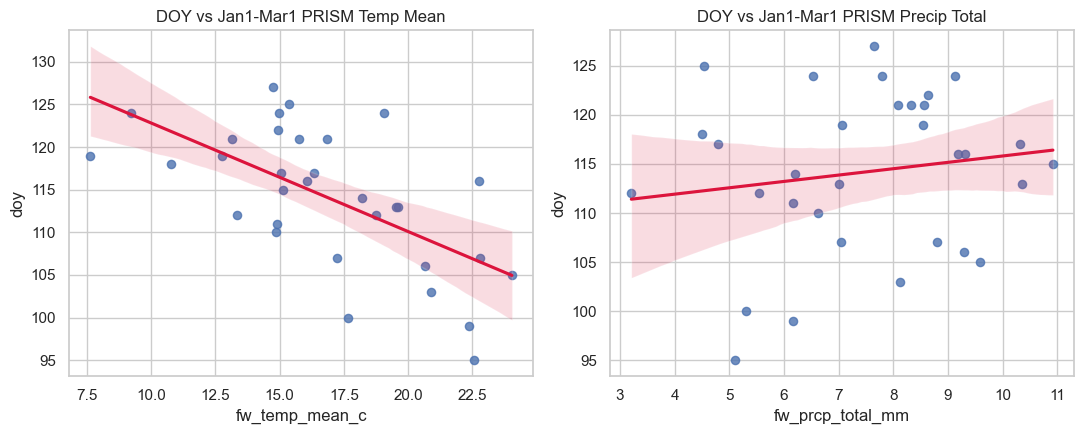

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.regplot(data=fixed_analysis_df, x="fw_temp_mean_c", y="doy", ax=axes[0], scatter_kws={"s": 35, "alpha": 0.8}, line_kws={"color": "crimson"})
axes[0].set_title("DOY vs Jan1-Mar1 PRISM Temp Mean")

sns.regplot(data=fixed_analysis_df, x="fw_prcp_total_mm", y="doy", ax=axes[1], scatter_kws={"s": 35, "alpha": 0.8}, line_kws={"color": "crimson"})
axes[1].set_title("DOY vs Jan1-Mar1 PRISM Precip Total")

plt.tight_layout()
plt.show()